In [3]:
from typing import  Optional
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker

def comp_avrg_event_duration(dir: str,
                             mag_range: Optional[tuple] or Optional[float] = None,
                             log_base: Optional[float] = np.e,
                             major_tick_interval: Optional[float] = 0.1,
                             marker_style: Optional[str] = 'o',
                             linestyle: Optional[str] = '-',
                             color: Optional[str] = 'b',
                             cmap : Optional[str] = None,
                             label: Optional[str] = '',
                             filter_slow_slip : bool = False,
                             fig_ax = None):
    if not isinstance(mag_range, tuple) and not isinstance(mag_range, (float,int)) and not mag_range == None:
        raise TypeError("mag_range must be either a tuple or a float")
    if  not isinstance(marker_style, str) or not isinstance(color, str):
        raise TypeError('marker_style, major_tick_interval, and color must be strings')
    try:
        log_base = float(log_base)
    except:
        raise TypeError("log_base must be a number")
    if fig_ax: fig = fig_ax[0] ; ax = fig_ax[1] ;ax.set_ylabel('Event duration', size=20);ax.set_xlabel('Pore Pressure ratio', size=20)
    else: fig, ax = plt.subplots(figsize=(10, 7.5))
    ax.grid(visible=True, which='major', linestyle='--')
    pprs = []
    time_avrgs = []

    for filename in realsorted(os.listdir(dir)):
        if filename == ".DS_Store":
            continue
        pprs.append(float(filename.split('=')[-1].removesuffix('.npy')))
        a = filename.split('=')[-2].removesuffix('_ppr')

        events = np.load(dir + '/' + filename, allow_pickle=True)
        events = np.vstack(events)
        with np.errstate(divide="ignore", invalid="ignore"):
            events[:, 2] = np.log(events[:, 2]) / np.log(log_base)
        if filter_slow_slip:
            events = events[events[:,0] > 5000]
            events = events[(events[:,1] - events[:,0]) < 75]
        if type(mag_range) == tuple:
            lower = mag_range[0];
            upper = mag_range[1]
            rel_events = events[(events[:, 2] > lower) & (events[:, 2] < upper)]

        if type(mag_range) == float or type(mag_range) == int:
            rel_events = events[events[:, 2] > mag_range]
        elif not mag_range:
            rel_events = events

        times = rel_events[:, 1] - rel_events[:, 0]
        time_avrgs.append(np.mean(times))




    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_tick_interval))
    ax.plot(pprs, time_avrgs, marker=marker_style, linestyle=linestyle, c=color, label=label)
    return fig, ax

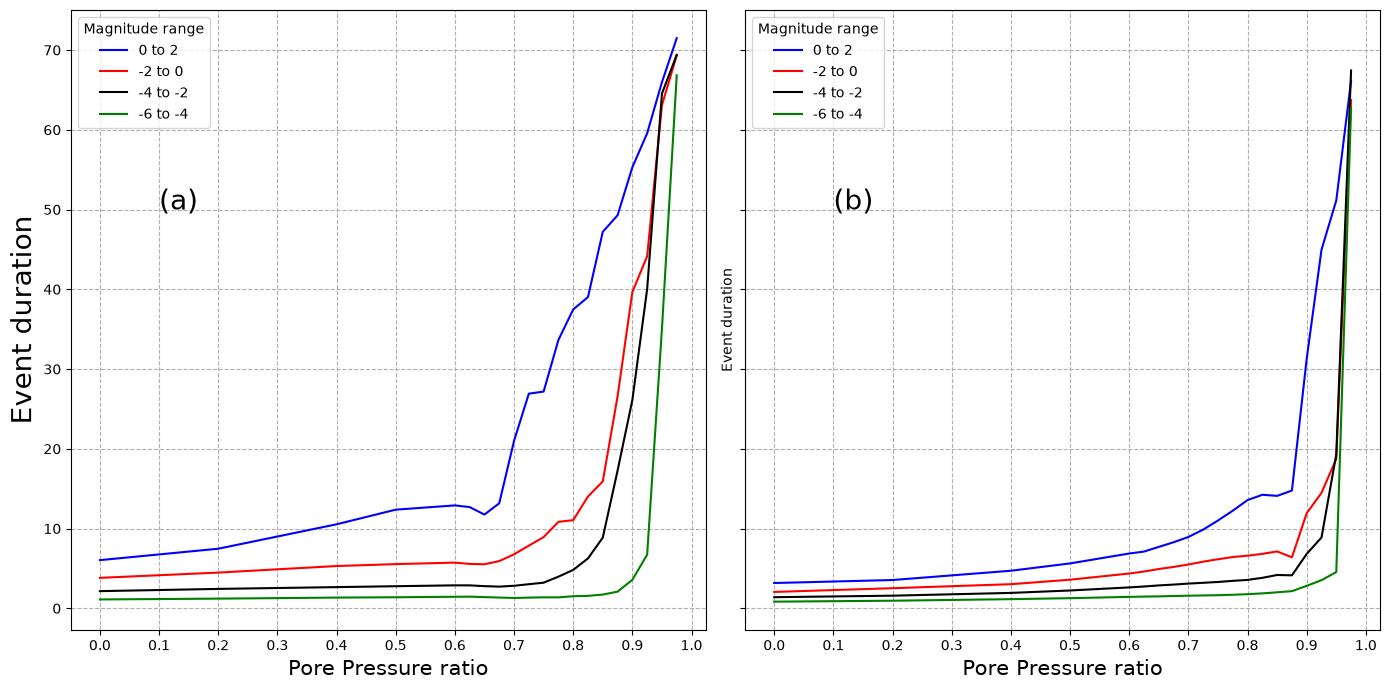

In [73]:

fig, axs = plt.subplots(1,2, figsize=(14,7), sharey=True)
ax = axs[0] ; ax2 = axs[1]
ax.text(s=f'(a)', x=0.1, y=50, size=20)
ax2.text(s=f'(b)', x=0.1, y=50, size=20)


plt.style.use('default')


comp_avrg_event_duration(
    'Constant pore pressure/Alpha 1 with nuleation',
    mag_range=(0,2),marker_style='', fig_ax=(fig,ax), label=f'0 to 2', color='blue', filter_slow_slip=False  )

comp_avrg_event_duration(
    'Constant pore pressure/Alpha 1 with nuleation',
    mag_range=(-2,0),marker_style='', fig_ax=(fig,ax), color='red', label=f'-2 to 0' , filter_slow_slip=False  )
comp_avrg_event_duration(
    'Constant pore pressure/Alpha 1 with nuleation',
    mag_range=(-4,-2),marker_style='', fig_ax=(fig,ax), color='black', label=f'-4 to -2' , filter_slow_slip=False  )

comp_avrg_event_duration(
    'Constant pore pressure/Alpha 1 with nuleation',
    mag_range=(-6,-4),marker_style='', fig_ax=(fig,ax), color='green', label=f'-6 to -4', filter_slow_slip=False    )

comp_avrg_event_duration(
    'Constant pore pressure/Alpha 3 with nuleation',
    mag_range=(0,2),marker_style='', fig_ax=(fig,ax2), label=f'0 to 2'  )

comp_avrg_event_duration(
    'Constant pore pressure/Alpha 3 with nuleation',
    mag_range=(-2,0),marker_style='', fig_ax=(fig,ax2), color='red', label=f'-2 to 0'  )
comp_avrg_event_duration(
    'Constant pore pressure/Alpha 3 with nuleation',
    mag_range=(-4,-2),marker_style='', fig_ax=(fig,ax2), color='black', label=f'-4 to -2'  )

comp_avrg_event_duration(
    'Constant pore pressure/Alpha 3 with nuleation',
    mag_range=(-6,-4),marker_style='', fig_ax=(fig,ax2), color='green', label=f'-6 to -4'   )

ax.legend(title='Magnitude range')
ax2.legend(title='Magnitude range')
ax.set_ylabel('Event duration', size=20)
ax.set_xlabel('Pore Pressure ratio', size=15)
ax2.set_xlabel('Pore Pressure ratio', size=15)
fig.tight_layout()

In [14]:
import numpy as np
import os
import matplotlib.pyplot as plt
from event_analysis import recurrence_time, preceding_event_locality, log_binned_recurrence_distribution


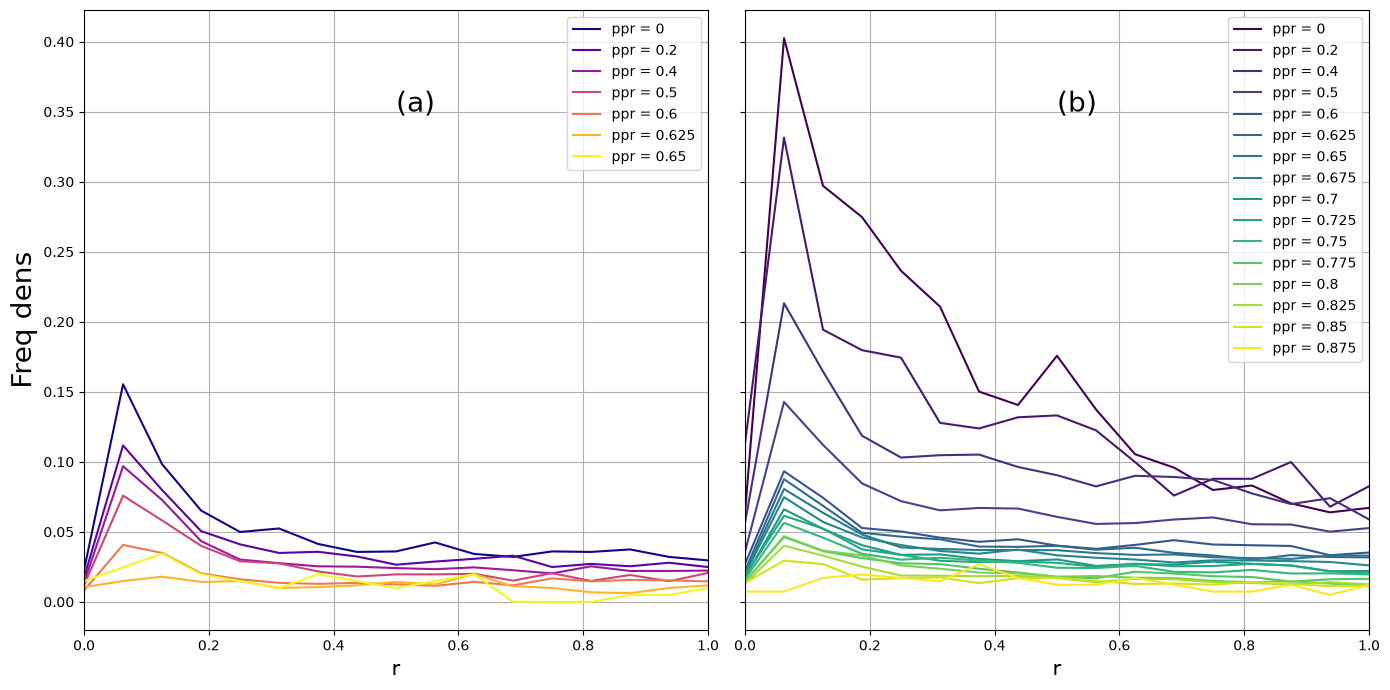

In [64]:
from natsort import realsorted
plt.style.use('default')
dir1 = 'Constant pore pressure/Alpha 1 with nuleation'
dir2 = 'Constant pore pressure/Alpha 3 with nuleation'

cmap_p_rect = plt.get_cmap('plasma',7).colors
cmap_v_rect = plt.get_cmap('viridis', 16).colors

fig, axs = plt.subplots(1,2,figsize=(14,7), sharey=True)
ax = axs[0]; ax1 = axs[1]
ax1.grid(visible=True, which='major', linestyle='-'); ax.grid(visible=True, which='major', linestyle='-')
ax.set_ylabel('Freq dens', size=20)
ax.set_xlabel('r', size=15)
ax1.set_xlabel('r', size=15)
ax.text(0.5,0.35, '(a)', size=20)
ax1.text(0.5,0.35, '(b)', size=20)

for n, filename in enumerate(realsorted(os.listdir(dir1)), start=0):

    if filename == ".DS_Store":
        continue
    if filename in ['events_SRF_PPcont_alpha=1=_n=0.02_a=0.0625_ppr=0.925.npy', 'events_SRF_PPcont_alpha=1=_n=0.02_a=0.0625_ppr=0.975.npy', 'events_SRF_PPcont_alpha=1=_n=0.02_a=0.0625_ppr=0.95.npy']:
        continue
    ppr = filename.split('=')[-1].removesuffix('.npy')
    a = filename.split('=')[-2].removesuffix('_ppr')
    alpha = filename.split('=')[1]

    events = np.load(dir1+ '/' + filename, allow_pickle=True)

    events = np.vstack(events)
    events = events[events[:,0] > 5000]
    events = events[(events[:,1] - events[:,0]) < 75]

    r = preceding_event_locality(events, min_mag=0, preceeding_time=10, element_size=float(a), epicenter_col=3)
    if not len(r) == 0:
        bin_size = float(a)
        bins = np.arange(np.min(r), np.max(r) + bin_size, bin_size)
        freq_den, bin_edge = np.histogram(r, bins = bins, density=True)
        ax.plot(bin_edge[:-1], freq_den, label=f'ppr = {ppr}', color=cmap_p_rect[n-1])

for n, filename in enumerate(realsorted(os.listdir(dir2)), start=0):

    if filename == ".DS_Store":
        continue


    ppr = filename.split('=')[-1].removesuffix('.npy')
    a = filename.split('=')[-2].removesuffix('_ppr')
    alpha = filename.split('=')[1]

    events = np.load(dir2+ '/' + filename, allow_pickle=True)

    events = np.vstack(events)
    events = events[events[:,0] > 5000]
    events = events[(events[:,1] - events[:,0]) < 75]

    r = preceding_event_locality(events, min_mag=0, preceeding_time=10, element_size=float(a), epicenter_col=3)
    if not len(r) == 0:
        bin_size = float(a)
        bins = np.arange(np.min(r), np.max(r) + bin_size, bin_size)
        freq_den, bin_edge = np.histogram(r, bins = bins, density=True)
        ax1.plot(bin_edge[:-1], freq_den, label=f'ppr = {ppr}', color=cmap_v_rect[n-1])

ax.set_xlim((0,1.0))
ax1.set_xlim((0,1.0))
#ax1.set_ylim(())
ax.legend()
ax1.legend()
fig.tight_layout()


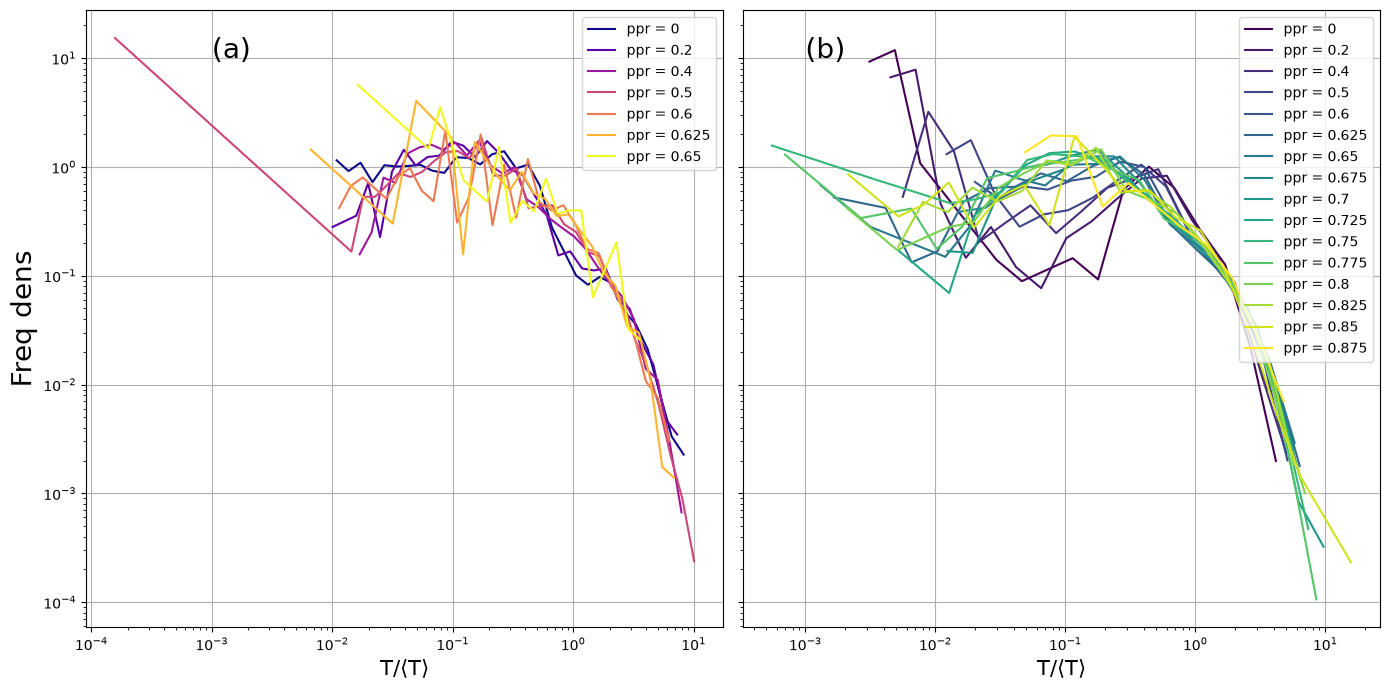

In [69]:
from natsort import realsorted
plt.style.use('default')
dir1 = 'Constant pore pressure/Alpha 1 with nuleation'
dir2 = 'Constant pore pressure/Alpha 3 with nuleation'

cmap_p_rect = plt.get_cmap('plasma',7).colors
cmap_v_rect = plt.get_cmap('viridis', 16).colors

fig, axs = plt.subplots(1,2,figsize=(14,7), sharey=True)
ax = axs[0]; ax1 = axs[1]
ax1.grid(visible=True, which='major', linestyle='-'); ax.grid(visible=True, which='major', linestyle='-')

ax.set_ylabel('Freq dens', size=20)
ax.set_xlabel('T/⟨T⟩', size=15)
ax1.set_xlabel('T/⟨T⟩', size=15)
ax.text(0.001,10, '(a)', size=20)
ax1.text(0.001,10, '(b)', size=20)


for n, filename in enumerate(realsorted(os.listdir(dir1)), start=0):

    if filename == ".DS_Store":
        continue
    if filename in ['events_SRF_PPcont_alpha=1=_n=0.02_a=0.0625_ppr=0.925.npy', 'events_SRF_PPcont_alpha=1=_n=0.02_a=0.0625_ppr=0.975.npy', 'events_SRF_PPcont_alpha=1=_n=0.02_a=0.0625_ppr=0.95.npy']:
        continue
    ppr = filename.split('=')[-1].removesuffix('.npy')
    a = filename.split('=')[-2].removesuffix('_ppr')
    alpha = filename.split('=')[1]

    events = np.load(dir1+ '/' + filename, allow_pickle=True)

    events = np.vstack(events)
    events = events[events[:,0] > 5000]
    events = events[(events[:,1] - events[:,0]) < 75]

    rec_t = recurrence_time(events, r=7.5, min_mag=0, element_size=0.0625, epicenter_col=3, simulation_time_step=0.001)
    centers, freq_den, bin_edge, mean_t = log_binned_recurrence_distribution(rec_t, bins_per_decade=10, normalize_by_mean=True)
    keep = (freq_den > 0)

    if not centers.size == 0:
        #print(f"{ppr}: mean T={mean_t:.3g}, max T={np.max(rec_t):.3g}, n={rec_t.size}")
        ax.loglog(bin_edge[keep], freq_den[keep], label=f'ppr = {ppr}', marker ='', markersize=5, color=cmap_p_rect[n-1])



for n, filename in enumerate(realsorted(os.listdir(dir2)), start=0):

    if filename == ".DS_Store":
        continue


    ppr = filename.split('=')[-1].removesuffix('.npy')
    a = filename.split('=')[-2].removesuffix('_ppr')
    alpha = filename.split('=')[1]

    events = np.load(dir2+ '/' + filename, allow_pickle=True)

    events = np.vstack(events)
    events = events[events[:,0] > 5000]
    events = events[(events[:,1] - events[:,0]) < 75]

    rec_t = recurrence_time(events, r=7.5, min_mag=0, element_size=0.0625, epicenter_col=3, simulation_time_step=0.001)
    centers, freq_den, bin_edge, mean_t = log_binned_recurrence_distribution(rec_t, bins_per_decade=5, normalize_by_mean=True)
    keep = (freq_den > 0)

    if not centers.size == 0:
        #print(f"{ppr}: mean T={mean_t:.3g}, max T={np.max(rec_t):.3g}, n={rec_t.size}")
        ax1.loglog(bin_edge[keep], freq_den[keep], label=f'ppr = {ppr}', marker ='', markersize=5, color=cmap_v_rect[n-1])
ax.legend(loc = 'upper right')
ax1.legend(loc = 'upper right')
fig.tight_layout()